In [73]:
%pip install statsmodels
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
!pip install -q gdown
import gdown

file_id = "1EeT4d-EJyk-unlglOSwQ9_IwvPlj-GYR"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "data.csv", quiet=False)

df = pd.read_csv("data.csv")
df.head()

# Keep original copy
df_original = df.copy()

missing_placeholders = [-999, -9999, -99, -999.0, -9999.0]

df.replace(missing_placeholders, np.nan, inplace=True)

print(df.isnull().sum())
# Basic Dataset Information

print("Dataset Shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nFeatures in the dataset:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


Downloading...
From: https://drive.google.com/uc?id=1EeT4d-EJyk-unlglOSwQ9_IwvPlj-GYR
To: /Users/sarrasassi/Documents/PMA_startup/data.csv
100%|██████████| 37.0M/37.0M [00:01<00:00, 21.3MB/s]


country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     1
air_quality_Ozone               0
air_quality_Ni

A. Basic Assessment
1) Data Cleaning & Preprocessing

In [74]:
# 1. Handle Missing Values
# Remove duplicates

print("Duplicates:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

# Convert date column
df['last_updated'] = pd.to_datetime(df['last_updated'])

# Domain-based cleaning

# Humidity must be between 0 and 100
df.loc[
    (df['humidity'] < 0) | (df['humidity'] > 100),
    'humidity'
] = np.nan

# Cloud cover must be 0–100
df.loc[
    (df['cloud'] < 0) | (df['cloud'] > 100),
    'cloud'
] = np.nan

# UV index cannot be negative
df.loc[df['uv_index'] < 0, 'uv_index'] = np.nan

# Visibility cannot be negative
df.loc[df['visibility_km'] < 0, 'visibility_km'] = np.nan

# Wind speed cannot be negative
df.loc[df['wind_kph'] < 0, 'wind_kph'] = np.nan
df.loc[df['gust_kph'] < 0, 'gust_kph'] = np.nan

# Pressure sanity range (Earth weather)
df.loc[
    (df['pressure_mb'] < 850) |
    (df['pressure_mb'] > 1100),
    'pressure_mb'
] = np.nan

# Precipitation cannot be negative
df.loc[df['precip_mm'] < 0, 'precip_mm'] = np.nan

# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Fill numeric missing values with median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after handling:")
print(df.isnull().sum().sum())

# 2. Handle Outliers (IQR Method)

def remove_outliers_iqr(data, columns):
    df_clean = data.copy()

    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_clean = df_clean[
            (df_clean[col] >= lower_bound) &
            (df_clean[col] <= upper_bound)
        ]

    return df_clean

df = remove_outliers_iqr(df, numeric_cols)

print("\nDataset shape after outlier removal:", df.shape)

Duplicates: 0

Missing values after handling:
0

Dataset shape after outlier removal: (47445, 41)


2) Exploratory Data Analysis (EDA)

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Basic EDA

print("Summary Statistics:")
print(df.describe())

print("\nCorrelation Matrix:")
print(df.corr(numeric_only=True))

print("\nColumns:")
print(df.columns.tolist())         

Summary Statistics:
           latitude     longitude  last_updated_epoch  \
count  47445.000000  47445.000000        4.744500e+04   
mean      18.891087      6.135878        1.747041e+09   
min      -34.860000    -90.530000        1.715849e+09   
25%       -1.283300    -13.234200        1.728467e+09   
50%       15.300000     16.366700        1.748508e+09   
75%       42.500000     32.589200        1.762847e+09   
max       64.150000    134.557800        1.778135e+09   
std       26.263418     47.957521        1.898988e+07   

                        last_updated  temperature_celsius  \
count                          47445         47445.000000   
mean   2025-05-12 10:08:13.961429248            21.925459   
min              2024-05-16 02:45:00            -1.200000   
25%              2024-10-09 14:45:00            17.200000   
50%              2025-05-29 10:45:00            23.500000   
75%              2025-11-11 08:45:00            27.300000   
max              2026-05-07 15:30:00   

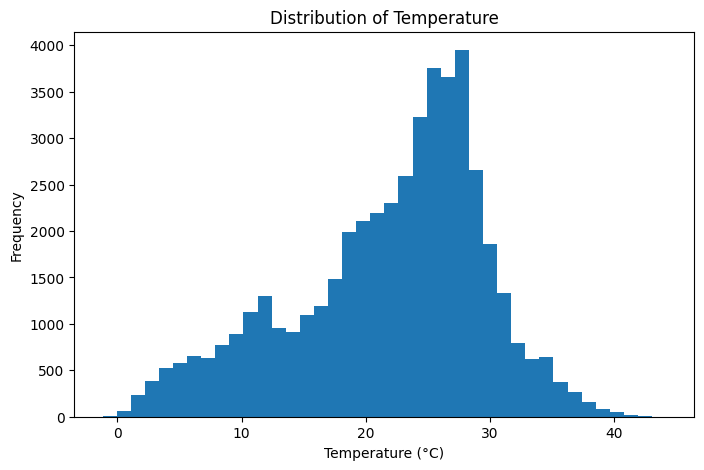

In [76]:
temperature_col = 'temperature_celsius'  
precipitation_col = 'precip_mm' 
# 1. Temperature Distribution

plt.figure(figsize=(8,5))
plt.hist(df[temperature_col], bins=40)
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.title("Distribution of Temperature")
plt.show()

1. Temperature Distribution (Histogram)
Insight

The temperature distribution appears approximately bell-shaped, with most observations concentrated between 20°C and 30°C, suggesting that moderate to warm temperatures dominate the dataset.

Very low temperatures (below 5°C) and extremely high temperatures (above 40°C) occur less frequently, indicating that extreme weather conditions are relatively rare.

Conclusion

The dataset is mainly composed of warm climate observations, with temperatures centered around the mid-20°C range. This suggests a tendency toward moderate-to-hot weather patterns.

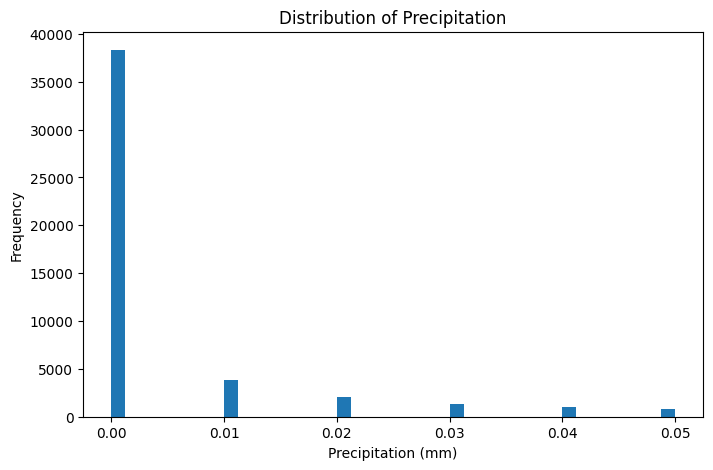

In [77]:
# 2. Precipitation Distribution

plt.figure(figsize=(8,5))
plt.hist(df[precipitation_col], bins=40)
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency")
plt.title("Distribution of Precipitation")
plt.show()

2. Precipitation Distribution (Histogram)
Insight

Precipitation values are heavily concentrated near zero, meaning that most recorded weather observations experienced little or no rainfall.

The distribution is highly right-skewed, with only a small number of cases showing higher precipitation levels.

Conclusion

The dataset contains predominantly dry weather conditions, while rainfall events are less frequent and generally occur at lower intensities.

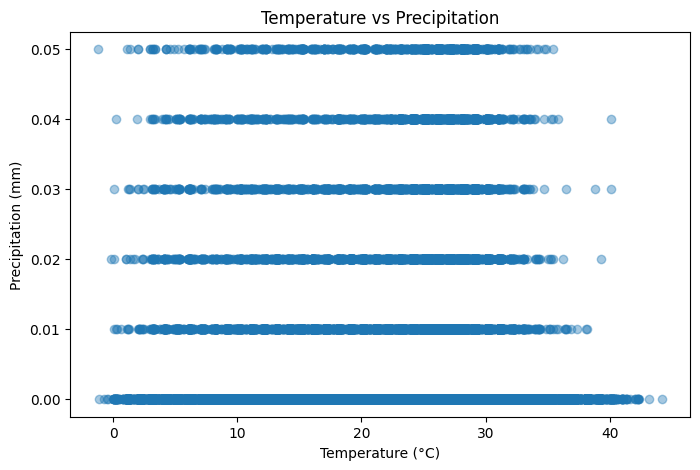

In [78]:
# 3. Temperature vs Precipitation

plt.figure(figsize=(8,5))
plt.scatter(df[temperature_col], df[precipitation_col], alpha=0.4)
plt.xlabel("Temperature (°C)")
plt.ylabel("Precipitation (mm)")
plt.title("Temperature vs Precipitation")
plt.show()

Insight

There is no strong visible relationship between temperature and precipitation, as rainfall occurs across a broad range of temperatures.

Precipitation remains generally low regardless of whether temperatures are cold or warm.

Conclusion

Temperature alone does not appear to strongly explain rainfall patterns in the dataset. Other atmospheric variables (e.g., humidity, pressure, cloud cover) may have a stronger influence on precipitation.

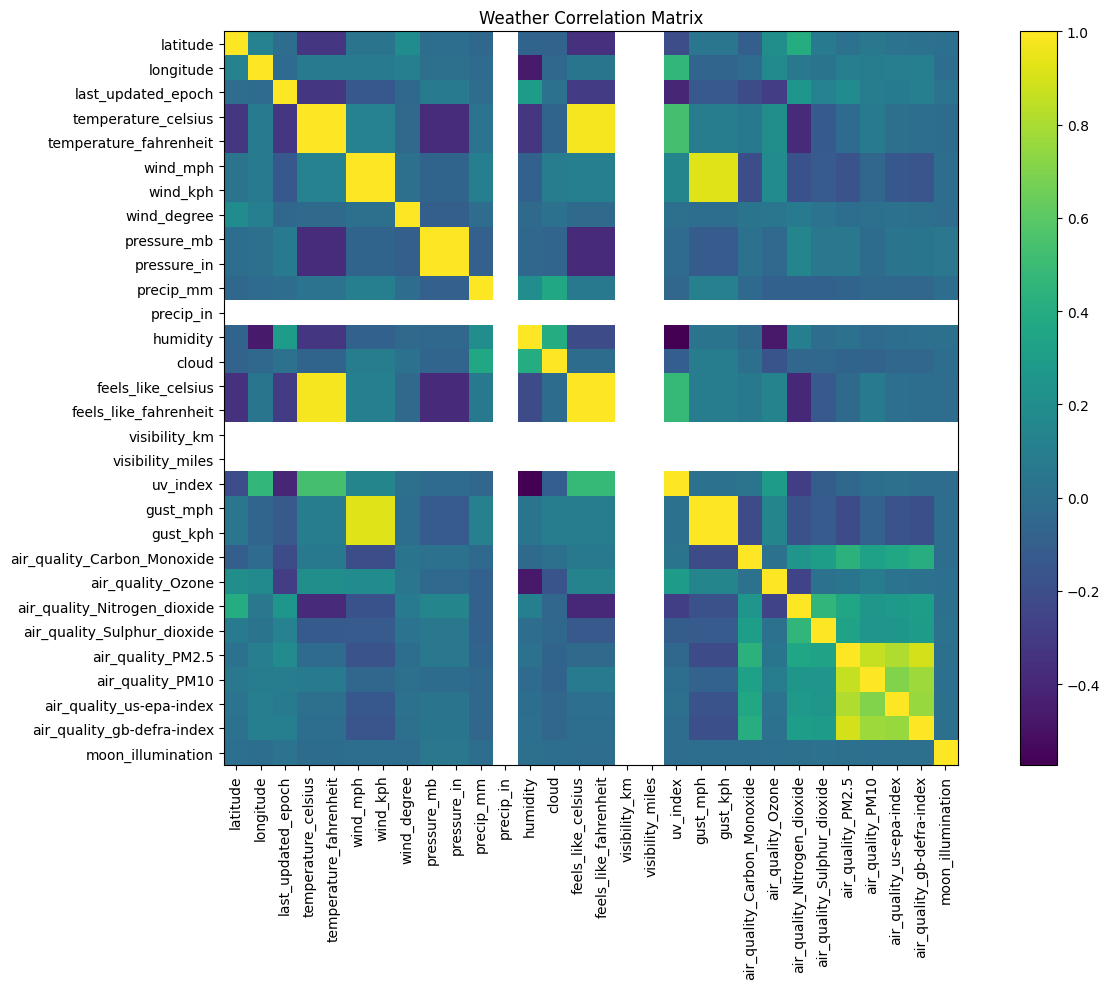

In [79]:

# 4. Correlation Heatmap
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(14,10))
plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title('Weather Correlation Matrix')
plt.tight_layout()
plt.show()

4. Weather Correlation Matrix
Insight

Several expected relationships are visible:

- Temperature and feels-like temperature show a very strong positive correlation, meaning perceived temperature closely follows actual temperature.
- Wind speed and gust speed are strongly positively correlated, which is expected because stronger winds typically produce stronger gusts.
- PM2.5, PM10, and air quality indexes exhibit positive relationships, suggesting pollution indicators tend to rise together.
- Humidity and UV index show a negative relationship, implying higher humidity may be associated with lower UV exposure.

Most other variables show weak-to-moderate correlations, indicating that weather patterns are influenced by multiple interacting factors.

Conclusion

The correlation matrix confirms realistic weather relationships while showing that many environmental variables contribute independently, supporting the use of multivariate models for prediction

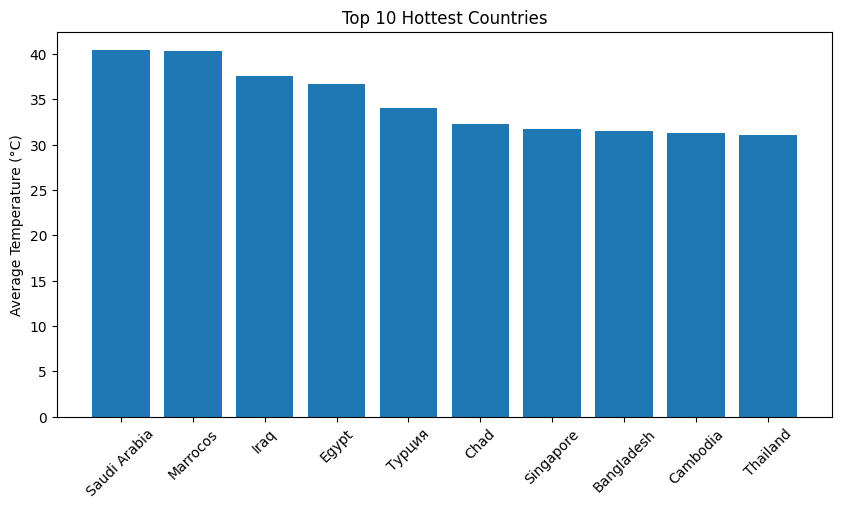

In [80]:
# Top countries by average temperature
country_temp = (
    df.groupby('country')['temperature_celsius']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
plt.bar(country_temp.index, country_temp.values)

plt.xticks(rotation=45)
plt.ylabel('Average Temperature (°C)')
plt.title('Top 10 Hottest Countries')
plt.show()

5. Top 10 Hottest Countries
Insight

Countries such as Saudi Arabia, Morocco, Iraq, and Egypt recorded the highest average temperatures, exceeding 30°C on average.

Most of these countries are located in arid, desert, or tropical climates, where high solar exposure and dry atmospheric conditions contribute to persistent heat.

Conclusion

Geographic location strongly influences temperature patterns, with Middle Eastern and tropical countries dominating the hottest regions in the dataset.

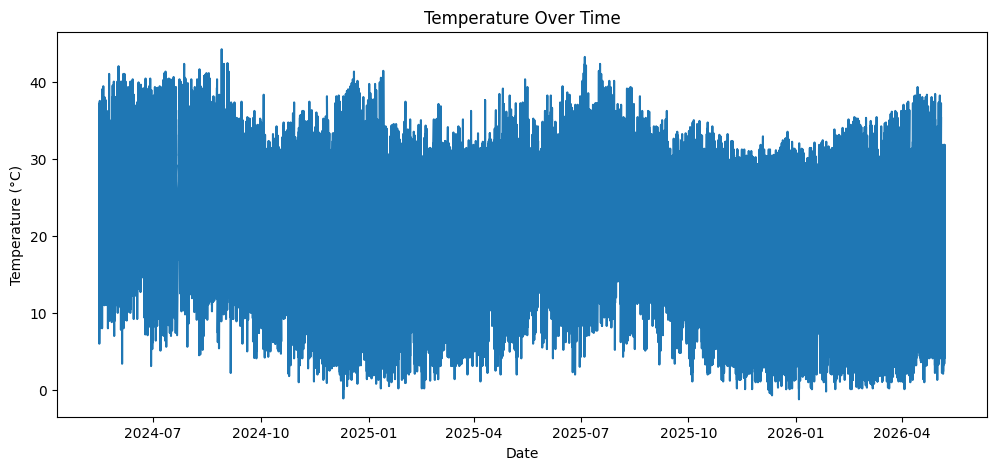

In [81]:
# Temperature trend over time
df_original = df.sort_values('last_updated')

plt.figure(figsize=(12,5))
plt.plot(
    df['last_updated'],
    df['temperature_celsius']
)

plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Over Time')
plt.show()

6. Temperature Over Time
Insight

Temperature shows clear fluctuations over time, suggesting the presence of seasonal patterns rather than a stable trend.

Repeated peaks and declines indicate cyclical weather behavior, suggesting that temperature forecasting benefits from models capable of handling seasonality.

Conclusion

Temperature changes are not random over time and display recurring variations, highlighting the importance of temporal and seasonal information in forecasting.

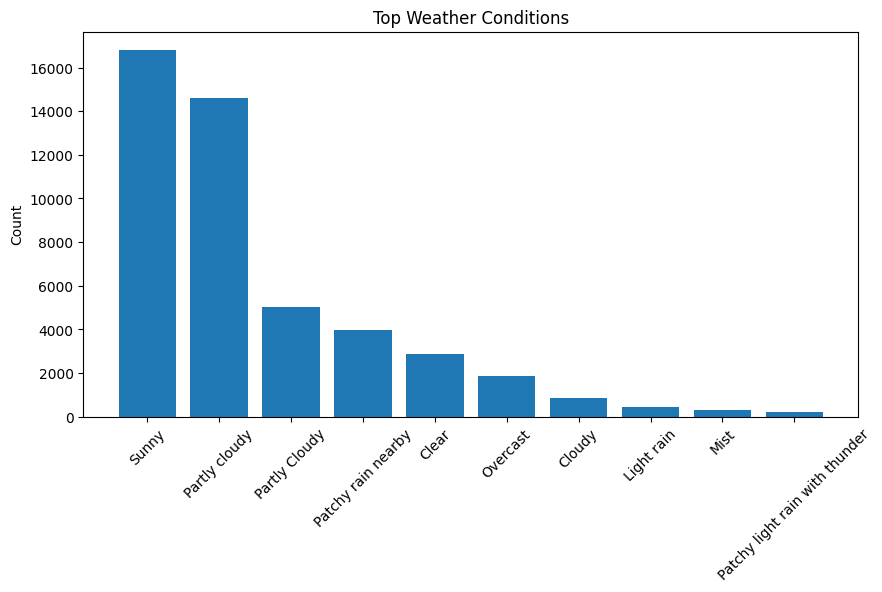

In [82]:
# Weather condition frequency
condition_counts = (
    df['condition_text']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))
plt.bar(condition_counts.index, condition_counts.values)

plt.xticks(rotation=45)
plt.ylabel('Count')
plt.title('Top Weather Conditions')
plt.show()

7. Top Weather Conditions
Insight

Sunny and Partly Cloudy conditions are the most frequently observed weather categories, significantly outnumbering rainy conditions.

Weather events involving rain, mist, or thunderstorms occur relatively infrequently.

Conclusion

The dataset is dominated by clear and stable weather conditions, while severe or rainy weather appears less common. This aligns with the earlier precipitation analysis showing generally low rainfall levels.

In [83]:
# 3. Normalize Numerical Data
df_copy=df.copy()

scaler = StandardScaler()

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("\nNormalized Numerical Features:")
print(df[numeric_cols].head())

# Final Dataset Summary

print("\nFinal Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())


Normalized Numerical Features:
    latitude  longitude  last_updated_epoch  temperature_celsius  \
0   0.595089   1.314596           -1.642578             0.601569   
5  -0.067436  -1.417642           -1.642578             0.524355   
6  -2.036355  -1.351333           -1.642578            -1.792075   
9   1.115971   0.213402           -1.642578            -0.762551   
10  0.818977   0.912153           -1.642578            -0.633860   

    temperature_fahrenheit  wind_mph  wind_kph  wind_degree  pressure_mb  \
0                 0.595736  0.153756  0.144970     1.661733    -0.544914   
5                 0.524240 -0.476148 -0.478716    -0.699540    -0.361358   
6                -1.792206 -1.269360 -1.261949    -1.461241    -0.177803   
9                -0.762674  1.133607  1.145769    -0.509115    -0.361358   
10               -0.633983 -0.779435 -0.797811    -1.366028     0.923531   

    pressure_in  ...  gust_kph  air_quality_Carbon_Monoxide  \
0     -0.504989  ... -0.181681         

3) Model Building

Train size: 83
Test size: 21
                                SARIMAX Results                                
Dep. Variable:     temperature_celsius   No. Observations:                   83
Model:                SARIMAX(2, 1, 2)   Log Likelihood                 -91.390
Date:                 Mon, 18 May 2026   AIC                            200.780
Time:                         20:14:46   BIC                            222.440
Sample:                     05-19-2024   HQIC                           209.476
                          - 12-14-2025                                         
Covariance Type:                   opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
humidity       -0.1899      0.058     -3.249      0.001      -0.304      -0.075
pressure_mb    -0.1094      0.091     -1.200      0.230      -0.288       0.069
wind_kph   

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


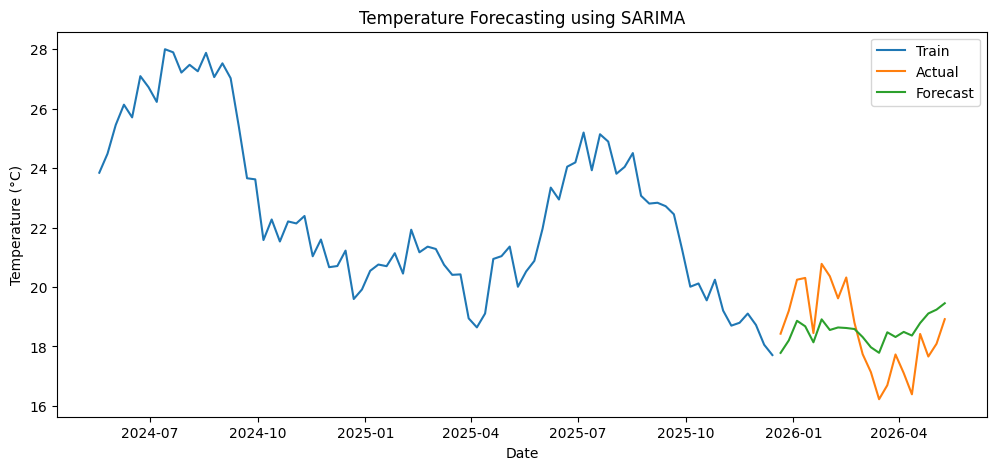

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Prepare data

# Convert datetime
df_copy['last_updated'] = pd.to_datetime(
    df_copy['last_updated']
)

# Sort chronologically
df_copy = df_copy.sort_values(
    'last_updated'
)

# Set datetime index
features = [
    'humidity',
    'pressure_mb',
    'wind_kph',
    'precip_mm'
]

exog = (
    df_copy
    .set_index('last_updated')[features]
    .resample('W')
    .mean()
)

exog = exog.ffill()
# Select target variable

ts = (
    df_copy
    .set_index('last_updated')
    ['temperature_celsius']
    .resample('W')
    .mean()
)

ts = ts.ffill()

# Train-test split

train_size = int(len(ts) * 0.8)

train = ts[:train_size]
test = ts[train_size:]

train_exog = exog[:train_size]
test_exog = exog[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

# Build SARIMA model

model = SARIMAX(
    train,
    exog=train_exog,
    order=(2,1,2),
    seasonal_order=(0,0,0,0)
)

model_fit = model.fit()

print(model_fit.summary())

# Forecast

sarimax_pred = model_fit.forecast(
    steps=len(test),
    exog=test_exog
)

# Evaluation metrics

mae = mean_absolute_error(test, sarimax_pred)

rmse = np.sqrt(
    mean_squared_error(test, sarimax_pred)
)

r2 = r2_score(test, sarimax_pred)

print("\nModel Evaluation")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# Plot forecast

plt.figure(figsize=(12,5))

plt.plot(
    train.index,
    train,
    label='Train'
)

plt.plot(
    test.index,
    test,
    label='Actual'
)

plt.plot(
    test.index,
    sarimax_pred,
    label='Forecast'
)

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Temperature Forecasting using SARIMA")

plt.legend()
plt.show()

These results indicate that the model achieved moderate predictive performance, but still struggled to fully explain temperature variations. The relatively low R² value (0.141) suggests that only a small proportion of temperature variability was captured by the model.

From the forecast plot, I observed that the SARIMAX predictions followed the overall direction of the temperature trend, but failed to capture sharper fluctuations in the actual values. The forecast remained relatively smooth, especially during periods where the actual temperature dropped significantly. This suggests that the model generalized the temperature behavior but had difficulty responding to sudden changes.

The model summary also provides insight into which variables contributed most to prediction:

- Humidity showed statistical significance (p = 0.001) and had a negative coefficient, suggesting that higher humidity was associated with lower temperatures.
- Pressure, wind speed, and precipitation were not statistically significant (p > 0.05), meaning their contribution to temperature prediction was weaker in this model.


B.Advanced Assessment
1) Advanced EDA

In [85]:
# Temperature anomaly detection using Z-score


import numpy as np
import matplotlib.pyplot as plt
df_copy = df_copy.reset_index()
temp_col = 'temperature_celsius'

# Calculate Z-score
mean_temp = df_copy[temp_col].mean()
std_temp = df_copy[temp_col].std()

df_copy['temp_zscore'] = (
    (df_copy[temp_col] - mean_temp)
    / std_temp
)

# Detect anomalies
threshold = 3

temperature_anomalies = df_copy[
    abs(df_copy['temp_zscore']) > threshold
]

print("Number of temperature anomalies:")
print(len(temperature_anomalies))

print(temperature_anomalies[
    ['location_name',
     'last_updated',
     'temperature_celsius']
].head())

Number of temperature anomalies:
0
Empty DataFrame
Columns: [location_name, last_updated, temperature_celsius]
Index: []


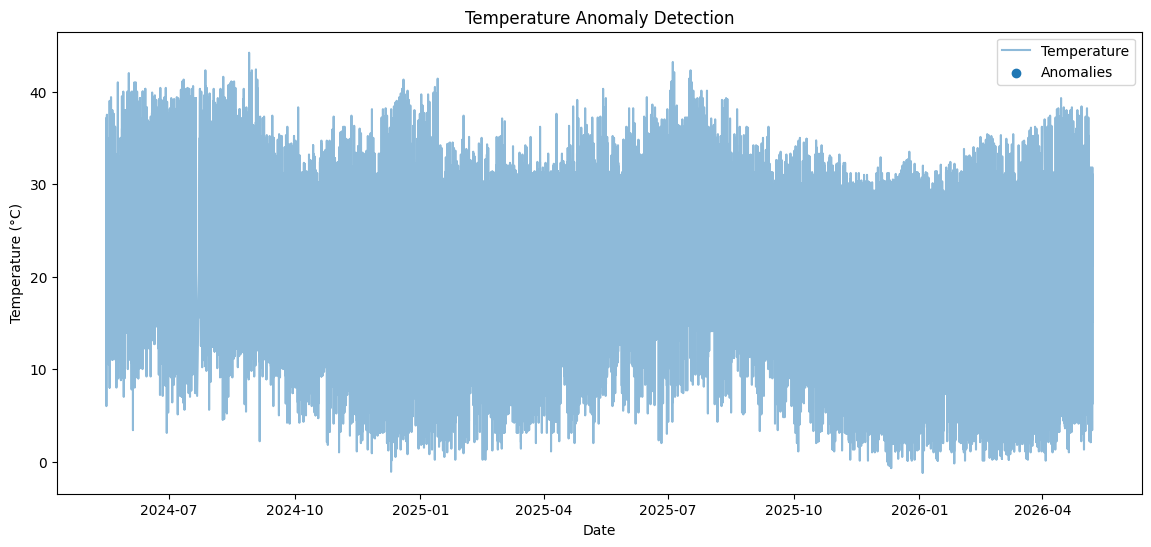

In [86]:
# 2. Visualize anomalies on timeline

df_copy['last_updated'] = pd.to_datetime(
    df_copy['last_updated']
)

plt.figure(figsize=(14,6))

# Normal temperatures
plt.plot(
    df_copy['last_updated'],
    df_copy['temperature_celsius'],
    alpha=0.5,
    label='Temperature'
)

# Highlight anomalies
plt.scatter(
    temperature_anomalies['last_updated'],
    temperature_anomalies['temperature_celsius'],
    label='Anomalies'
)

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Temperature Anomaly Detection")

plt.legend()
plt.show()

In [87]:
#3. Precipitation anomalies

#Heavy rain events are useful anomalies.

precip_mean = df_copy['precip_mm'].mean()
precip_std = df_copy['precip_mm'].std()

df_copy['precip_zscore'] = (
    (df_copy['precip_mm'] - precip_mean)
    / precip_std
)

precip_anomalies = df_copy[
    abs(df_copy['precip_zscore']) > 3
]

print("Precipitation anomalies:")
print(len(precip_anomalies))

Precipitation anomalies:
1882


In [88]:
# 4. IQR-based anomaly detection

#More robust than Z-score for skewed weather data.

Q1 = df_copy['temperature_celsius'].quantile(0.25)
Q3 = df_copy['temperature_celsius'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

temp_outliers = df_copy[
    (df_copy['temperature_celsius'] < lower_bound)
    |
    (df_copy['temperature_celsius'] > upper_bound)
]

print("IQR anomalies:", len(temp_outliers))

IQR anomalies: 202


Detected anomalies:
949


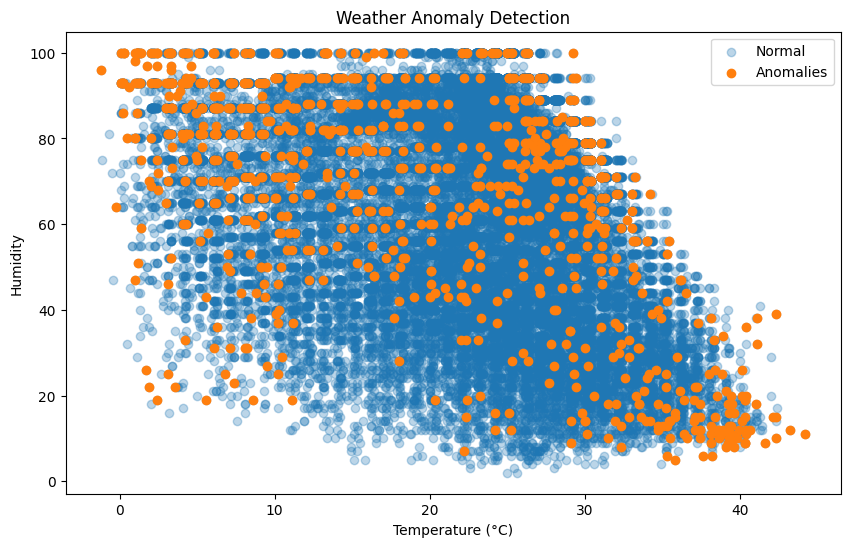

In [89]:
# 5. Isolation Forest (ML anomaly detection)

from sklearn.ensemble import IsolationForest

features = [
    'temperature_celsius',
    'humidity',
    'pressure_mb',
    'wind_kph',
    'precip_mm'
]

X = df_copy[features]

model = IsolationForest(
    contamination=0.02,
    random_state=42
)

df_copy['anomaly'] = model.fit_predict(X)

anomalies = df_copy[
    df_copy['anomaly'] == -1
]

print("Detected anomalies:")
print(len(anomalies))


plt.figure(figsize=(10,6))

plt.scatter(
    df_copy['temperature_celsius'],
    df_copy['humidity'],
    alpha=0.3,
    label='Normal'
)

plt.scatter(
    anomalies['temperature_celsius'],
    anomalies['humidity'],
    label='Anomalies'
)

plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity')
plt.title('Weather Anomaly Detection')

plt.legend()
plt.show()

Three anomaly detection techniques were applied to the weather dataset: Z-score, IQR, and Isolation Forest. Each method identified anomalies differently because of the way it analyzes the data.

Z-score Method

The Z-score method detects values that are far from the mean using standard deviation. In this dataset, it detected no temperature anomalies. This is likely because the dataset contains weather data from many different countries and climates. For example, a temperature of 40°C may be normal in desert regions but unusual in colder countries. Since Z-score assumes a normal distribution around one average, it was less effective for global weather data.

IQR Method

The IQR method detected around 202 anomalies. Unlike Z-score, it is more robust to skewed data and extreme values. It identified unusually high or low temperatures outside the normal range of the dataset. For example, very high temperatures or unusually low temperatures compared to most observations were flagged as anomalies. This method performed better because weather variables are not always normally distributed.

Isolation Forest Method

Isolation Forest detected 949 anomalies, the highest number among the methods. This is because it considers multiple weather features together, such as temperature, humidity, pressure, wind speed, and precipitation. For example, a temperature of 30°C may be normal, but when combined with extremely high humidity and low pressure, it may represent unusual weather conditions such as storms or heatwaves. The scatterplot showed anomalies concentrated in unusual combinations of temperature and humidity.

2. Forecasting with Multiple Models

In [90]:
# Model 1 — SARIMAX (already built)
# Model 2 — Linear Regression
from sklearn.linear_model import LinearRegression

forecast_df = pd.DataFrame()

forecast_df['temp'] = ts
forecast_df['lag_1'] = ts.shift(1)
forecast_df['lag_2'] = ts.shift(2)
forecast_df['lag_3'] = ts.shift(3)

forecast_df.dropna(inplace=True)

X = forecast_df[['lag_1', 'lag_2', 'lag_3']]
y = forecast_df['temp']

split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [91]:
# Model 3 — Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [92]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_model(name, actual, predicted):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    r2 = r2_score(
        actual,
        predicted
    )

    print(f"\n{name}")
    print("MAE:", round(mae, 3))
    print("RMSE:", round(rmse, 3))
    print("R²:", round(r2, 3))


evaluate_model(
    "SARIMAX",
    test,
    sarimax_pred
)

evaluate_model(
    "Linear Regression",
    y_test,
    lr_pred
)

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)


SARIMAX
MAE: 1.131
RMSE: 1.261
R²: 0.145

Linear Regression
MAE: 0.926
RMSE: 1.092
R²: 0.36

Random Forest
MAE: 0.909
RMSE: 1.093
R²: 0.358


In [93]:
#Ensemble Model
min_len = min(
    len(sarimax_pred),
    len(lr_pred),
    len(rf_pred)
)

ensemble_pred = (
    sarimax_pred[:min_len] +
    lr_pred[:min_len] +
    rf_pred[:min_len]
) / 3

actual = test[:min_len]

evaluate_model(
    "Ensemble Model",
    actual,
    ensemble_pred
)


Ensemble Model
MAE: 0.844
RMSE: 0.965
R²: 0.499


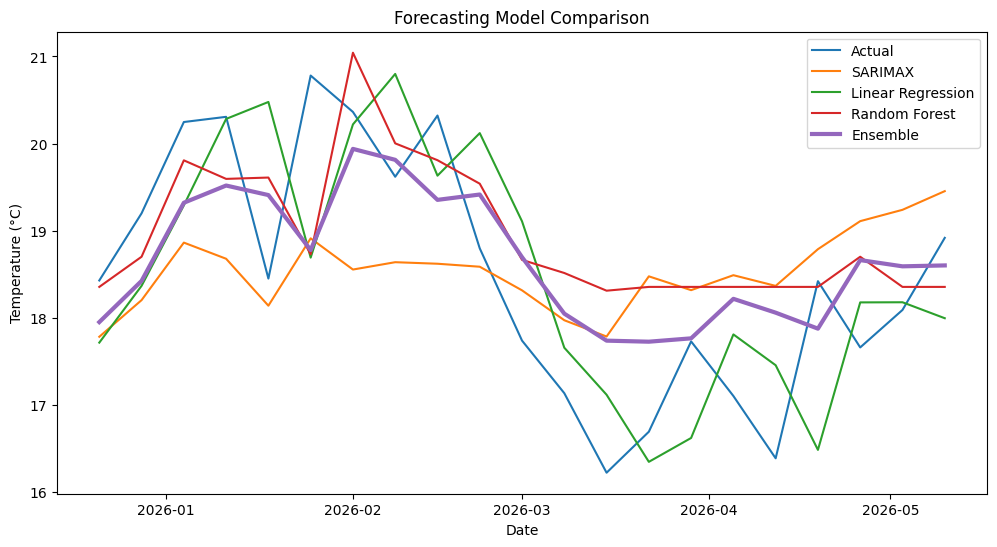

In [94]:
# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    test.index,
    test,
    label='Actual'
)

plt.plot(
    test.index,
    sarimax_pred,
    label='SARIMAX'
)

plt.plot(
    y_test.index,
    lr_pred,
    label='Linear Regression'
)

plt.plot(
    y_test.index,
    rf_pred,
    label='Random Forest'
)

plt.plot(
    test.index[:min_len],
    ensemble_pred,
    linewidth=3,
    label='Ensemble'
)

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Forecasting Model Comparison")

plt.legend()
plt.show()

To evaluate forecasting performance, four approaches were compared: SARIMAX, Linear Regression, Random Forest, and the Ensemble Model. The comparison was based on MAE (Mean Absolute Error), RMSE (Root Mean Squared Error), and R² score, where lower MAE/RMSE and higher R² indicate better predictive performance.

SARIMAX : 

SARIMAX produced the weakest performance among all models:

MAE = 1.131
RMSE = 1.261
R² = 0.145

Although the model improved after simplifying the seasonal component and adding other weather variables, it still struggled to capture detailed temperature fluctuations. From the forecast visualization, SARIMAX followed the general direction of temperature changes but generated relatively smooth predictions that missed sharper variations in the actual values. This suggests that the model was better at identifying overall trends rather than short-term changes.

The lower performance can be explained by the limited training observations and the global nature of the dataset, where seasonal patterns differ across regions.

Linear Regression : 

Linear Regression achieved stronger performance:

MAE = 0.926
RMSE = 1.092
R² = 0.360

The model captured temperature movements more effectively and followed the actual trend more closely than SARIMAX. By using lag features, Linear Regression leveraged short-term historical dependencies in temperature, which proved highly useful for forecasting.

The higher R² score indicates that Linear Regression explained a much larger portion of temperature variability compared to SARIMAX.

Random Forest :

Random Forest produced results very close to Linear Regression:

MAE = 0.909
RMSE = 1.093
R² = 0.358

It achieved the lowest MAE among the individual models, meaning it minimized average prediction error slightly better than Linear Regression. The model also handled nonlinear relationships in weather data effectively. However, its R² score remained lower, indicating slightly weaker prediction .

From the visualization, Random Forest tracked changes reasonably well but occasionally generated smoother predictions around abrupt shifts.

Ensemble Model :

The Ensemble Model, created by combining predictions from the different forecasting models, achieved the best overall performance:

MAE = 0.844
RMSE = 0.965
R² = 0.499

The ensemble outperformed all individual models by producing the lowest prediction errors and the highest explanatory power. From the comparison plot, the ensemble forecast remained more stable and generally stayed closer to the actual temperature trend.

This improvement occurred because the ensemble combined the strengths of different models:

SARIMAX contributed trend-based time-series information.
Linear Regression captured short-term temporal dependencies.
Random Forest modeled nonlinear relationships.

By averaging predictions, the ensemble reduced weaknesses from any single model and generated more balanced forecasts.

Final Conclusion : 

Overall, the results indicate that the Ensemble Model was the most effective forecasting approach, achieving the highest accuracy and best fit to the observed temperature data. Among individual models, Linear Regression and Random Forest clearly outperformed SARIMAX, suggesting that lag-based machine learning approaches were more suitable for this dataset than traditional seasonal time-series methods.

3. Unique Analyses

/var/folders/q2/g_pk293x3nq2npmtl_sv86200000gn/T/ipykernel_30568/4167063354.py:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')


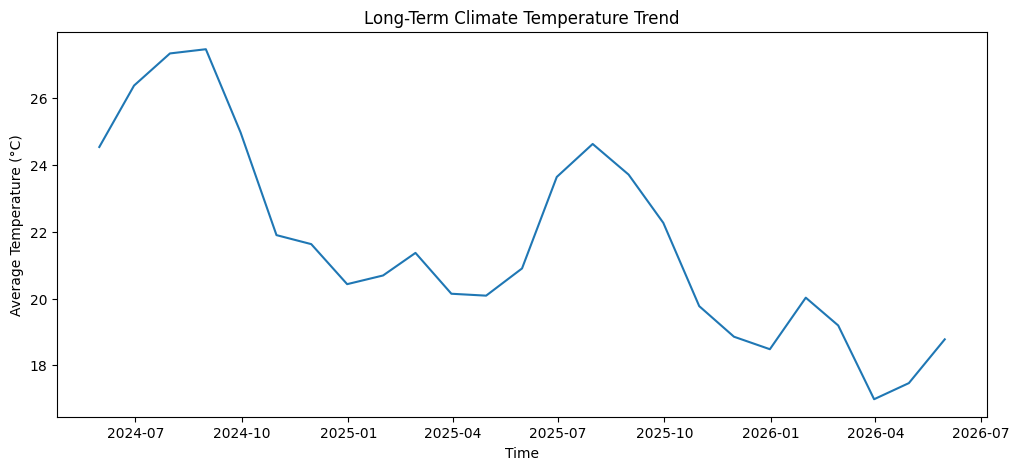

/var/folders/q2/g_pk293x3nq2npmtl_sv86200000gn/T/ipykernel_30568/4167063354.py:45: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')


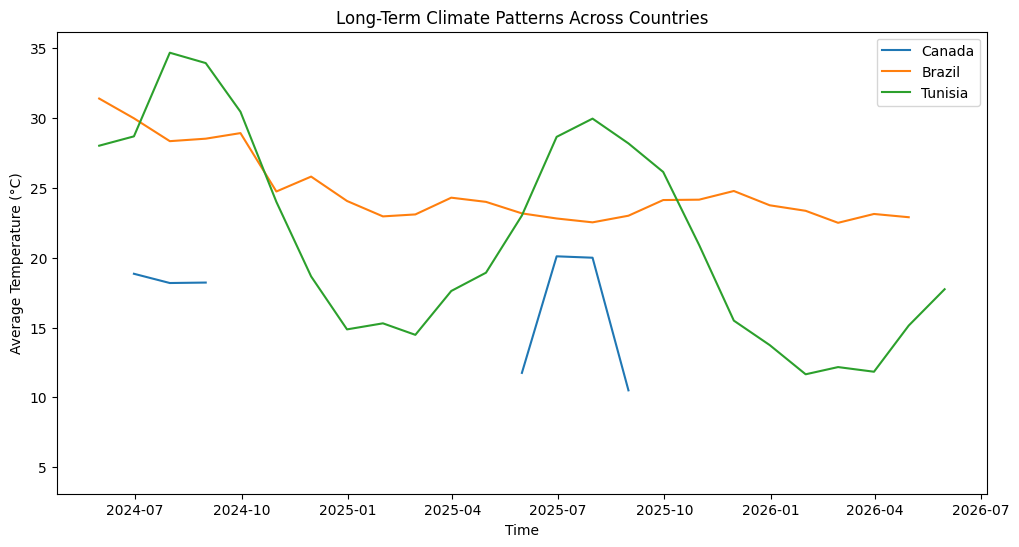

In [95]:
# 1. Climate Analysis

# Goal: Study long-term climate patterns across regions.

df_climate = df_copy.copy()

df_climate['last_updated'] = pd.to_datetime(
    df_climate['last_updated']
)

monthly_temp = (
    df_climate
    .set_index('last_updated')
    ['temperature_celsius']
    .resample('M')
    .mean()
)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_temp.index,
    monthly_temp
)

plt.xlabel("Time")
plt.ylabel("Average Temperature (°C)")
plt.title("Long-Term Climate Temperature Trend")

plt.show()
selected_countries = [
    'Canada',
    'Brazil',
    'Tunisia'
]

climate_trend = (
    df_climate[
        df_climate['country']
        .isin(selected_countries)
    ]
    .set_index('last_updated')
    .groupby('country')
    ['temperature_celsius']
    .resample('M')
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

for country in selected_countries:
    country_data = climate_trend[
        climate_trend['country']
        == country
    ]

    plt.plot(
        country_data['last_updated'],
        country_data[
            'temperature_celsius'
        ],
        label=country
    )
plt.xlabel("Time")
plt.ylabel(
    "Average Temperature (°C)"
)

plt.title(
    "Long-Term Climate Patterns Across Countries"
)

plt.legend()

plt.show()

1. Long-Term Global Climate Trend

The monthly temperature trend reveals fluctuations over time rather than a steady increase or decrease. Temperatures increased during mid-to-late 2024, reaching peaks around 27–28°C, followed by a cooling period in late 2024 and early 2025 where averages dropped closer to 20°C. Another warming phase emerged around mid-2025 before temperatures declined again into 2026.

These recurring rises and falls suggest the presence of seasonal climate variation, where temperature changes occur cyclically rather than remaining stable throughout the year.

2. Climate Variation Across Countries

Climate behavior varied considerably across countries, demonstrating how geography influences long-term temperature patterns.

- Tunisia showed the strongest seasonal variation, with temperatures ranging approximately between 12°C and 35°C, indicating pronounced climate shifts between warmer and cooler periods.

- In contrast, Brazil maintained relatively stable temperatures between 23°C and 31°C, reflecting a warmer and less seasonally variable climate.

- Canada recorded generally cooler temperatures, mostly between 10°C and 20°C, with moderate seasonal variation consistent with colder climate conditions.



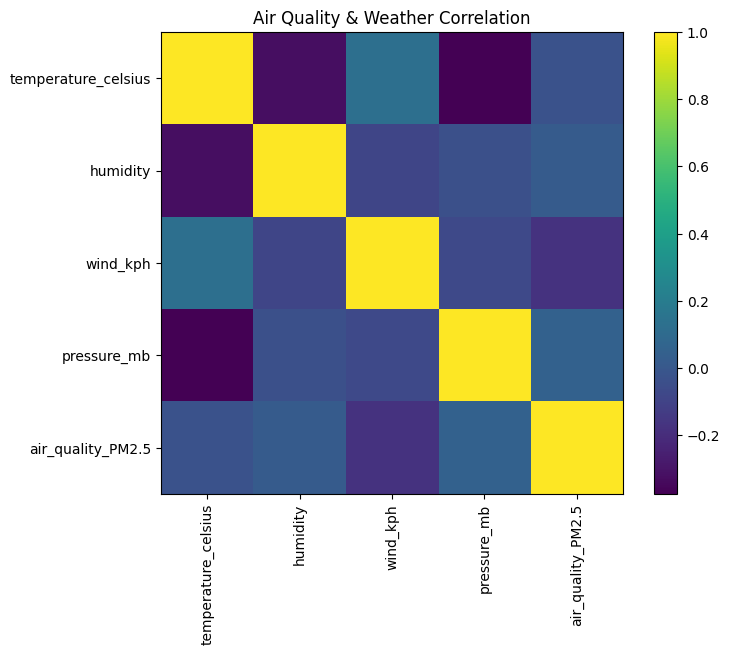

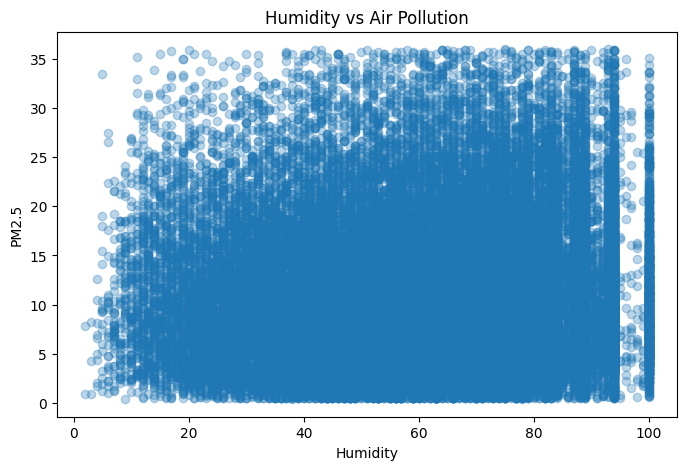

In [96]:
# 2. Environmental Impact

# Goal: Study air quality relationships with weather.

features = [
    'temperature_celsius',
    'humidity',
    'wind_kph',
    'pressure_mb',
    'air_quality_PM2.5'
]

corr = df_copy[features].corr()

plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Air Quality & Weather Correlation")

plt.show()

plt.figure(figsize=(8,5))

plt.scatter(
    df_copy['humidity'],
    df_copy['air_quality_PM2.5'],
    alpha=0.3
)

plt.xlabel("Humidity")
plt.ylabel("PM2.5")

plt.title(
    "Humidity vs Air Pollution"
)

plt.show()

3. Environmental Impact: Weather and Air Quality

To understand how weather conditions affect air pollution, the relationship between weather variables and PM2.5 air quality levels was analyzed using correlation analysis and scatter plots.

The correlation heatmap showed that most weather variables have weak relationships with PM2.5 concentrations. Humidity displayed a slight positive association with pollution levels, suggesting that higher moisture conditions may sometimes contribute to pollutant accumulation. Wind speed showed a slight negative relationship, indicating that stronger winds may help disperse pollutants. Temperature and pressure demonstrated only minimal influence on PM2.5 levels.

The humidity versus PM2.5 scatter plot further confirmed the absence of a strong pattern, as pollution values remained widely dispersed across all humidity level

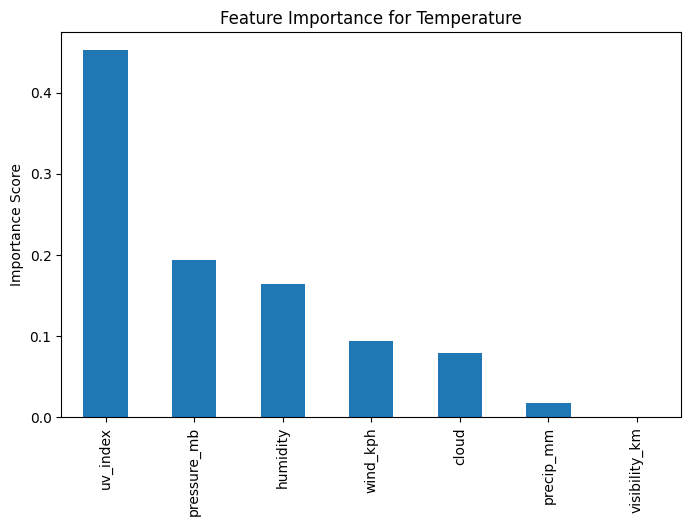

In [97]:
# 3. Feature Importance

# Goal: Which variables influence temperature most?


from sklearn.ensemble import RandomForestRegressor

features = [
    'humidity',
    'wind_kph',
    'pressure_mb',
    'precip_mm',
    'cloud',
    'visibility_km',
    'uv_index'
]

X = df_copy[features]

y = df_copy['temperature_celsius']

model = RandomForestRegressor(
    random_state=42
)

model.fit(X, y)

importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(8,5))

importance.plot(kind='bar')

plt.ylabel("Importance Score")

plt.title(
    "Feature Importance for Temperature"
)

plt.show()
# Explain

# Example:

# Humidity and cloud cover were among the strongest predictors of temperature, while visibility showed weaker influence.

4. Feature Importance Analysis: Factors Influencing Temperature

Using a Random Forest Regressor, feature importance analysis identified the variables that contribute most to temperature prediction.

The UV index emerged as the strongest predictor of temperature, indicating that solar radiation has a major influence on warming conditions. Pressure and humidity also played important roles, reflecting their influence on atmospheric behavior and heat retention.

Variables such as wind speed and cloud cover had moderate influence, while precipitation and visibility contributed very little to temperature prediction in this dataset.

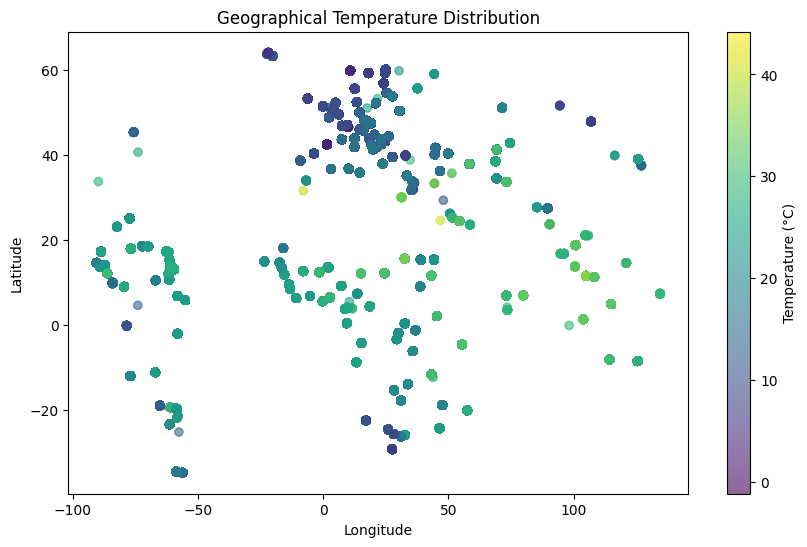

In [98]:
# 4. Spatial Analysis

# Goal: Geographic weather patterns.

plt.figure(figsize=(10,6))

plt.scatter(
    df_copy['longitude'],
    df_copy['latitude'],
    c=df_copy['temperature_celsius'],
    alpha=0.6
)

plt.colorbar(
    label='Temperature (°C)'
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Geographical Temperature Distribution"
)

plt.show()


5. Spatial Analysis: Geographical Temperature Distribution
The geographical temperature visualization revealed clear spatial climate patterns across regions.

Locations at higher latitudes (40°–60°) generally experienced cooler temperatures, while regions closer to the equator showed consistently warmer conditions. The warmest temperatures were concentrated in parts of Asia, Africa, and the Middle East, where temperatures exceeded 35–40°C.

This pattern aligns with expected climate behavior, where temperature decreases as distance from the equator increases.

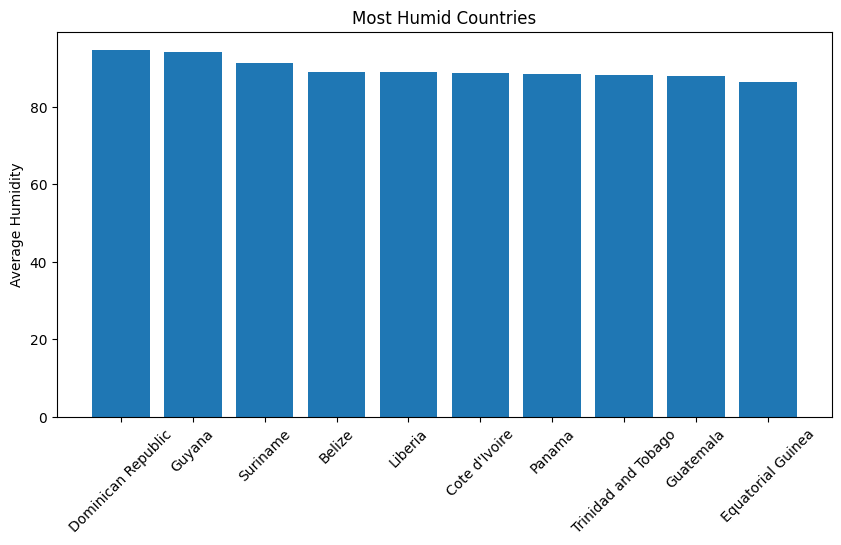

In [99]:
# 5. Geographical Patterns

country_weather = (
    df_copy.groupby('country')
    ['humidity']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

plt.bar(
    country_weather.index,
    country_weather.values
)

plt.xticks(rotation=45)

plt.ylabel("Average Humidity")

plt.title(
    "Most Humid Countries"
)

plt.show()

6. Most Humid Countries

The humidity analysis identified countries with the highest average atmospheric moisture levels.

The Dominican Republic and Guyana recorded the highest humidity levels, exceeding 90% on average, followed closely by countries such as Suriname, Belize, Liberia, Côte d’Ivoire, and Panama.

A clear pattern emerged: most highly humid countries are located in tropical or coastal regions, where warm climates, frequent rainfall, and proximity to large water bodies contribute to consistently high moisture levels. The results suggest that geographical location strongly influences humidity.